# SYDE1–FAK Cancer Dependency Project: Full Script Index (Start → Most Recent)

In [5]:
import os
import time
import pandas as pd
import numpy as np

print("Nam — initializing SYDE1–FAK Master Notebook...")
start_time = time.time()

# ---------------------------
# Directory setup
# ---------------------------
print("Setting up directories...")

DATA_DIR = "data"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"DATA_DIR set to: {DATA_DIR}")
print(f"OUT_DIR created at: {OUT_DIR}")

# ---------------------------
# Quick diagnostics
# ---------------------------
print("Checking expected DepMap files...")

expected_files = [
    "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
    "OmicsSomaticMutationsMatrixDamaging.csv",
    "OmicsSomaticMutationsMatrixHotspot.csv",
    "OmicsCNGeneWGS.csv",
    "CRISPRGeneDependency.csv"
]

for f in expected_files:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        print(f"✓ Found: {f}")
    else:
        print(f"✗ Missing: {f}  (not fatal yet)")

print("Environment initialized — ready for preprocessing steps.")
print(f"Elapsed: {time.time() - start_time:.2f} seconds")

Nam — initializing SYDE1–FAK Master Notebook...
Setting up directories...
DATA_DIR set to: data
OUT_DIR created at: outputs
Checking expected DepMap files...
✓ Found: OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
✓ Found: OmicsSomaticMutationsMatrixDamaging.csv
✓ Found: OmicsSomaticMutationsMatrixHotspot.csv
✓ Found: OmicsCNGeneWGS.csv
✓ Found: CRISPRGeneDependency.csv
Environment initialized — ready for preprocessing steps.
Elapsed: 0.00 seconds


It loaded OS, time, pandas, and numpy, then it defined the 2 folders and verified the depmap files exist

In [6]:
import pandas as pd
import numpy as np
import os

print("Loading helper functions...")

# ----------------------------------------
# Metadata columns likely to drop
# ----------------------------------------
META_COLS_CANDIDATES = {
    "common": {
        "Unnamed: 0", "SequencingID", "IsDefaultEntryForModel", "ModelConditionID",
        "ProfileID", "DataType", "Stranded", "SequencingDate", "DepMapCode",
        "Lineage", "CellFormat", "GrowthMedia", "GrowthPattern", "SourceModelCondition"
    }
}

def drop_metadata_cols(df: pd.DataFrame, keep: set = None) -> pd.DataFrame:
    """Drop obvious metadata columns if present (unless in keep)."""
    if keep is None:
        keep = set()
    drop_cols = [c for c in df.columns if c in META_COLS_CANDIDATES["common"] and c not in keep]
    return df.drop(columns=drop_cols, errors="ignore")

def set_index_on_modelid(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Ensure ModelID is the index. If both index and column contain ModelID,
    prefer the column.
    """
    if "ModelID" in df.columns:
        return df.set_index("ModelID", drop=True)

    # If ModelID is not a column but index name is wrong → fatal error
    if df.index.name != "ModelID":
        raise ValueError(f"[{dataset_name}] No 'ModelID' column or index found.")

    return df

def coerce_numeric_frame(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Convert all columns to numeric if possible. Drop all-NaN columns."""
    numeric_df = df.apply(pd.to_numeric, errors="coerce")

    all_nan_cols = numeric_df.columns[numeric_df.isna().all()]
    if len(all_nan_cols) > 0:
        print(f"[{dataset_name}] Dropping {len(all_nan_cols)} non-numeric columns.")
        numeric_df = numeric_df.drop(columns=list(all_nan_cols))

    return numeric_df

def binarize_any_nonzero(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Any non-zero → 1; zero or NaN → 0."""
    df = df.fillna(0)
    return (df != 0).astype(np.int8)

def binarize_cnv_loss(df: pd.DataFrame, threshold: float, dataset_name: str) -> pd.DataFrame:
    """CNV loss detection: value < threshold → 1. NaN → 0."""
    df = df.fillna(0)
    return (df < threshold).astype(np.int8)

def load_omics_table(path: str, dataset_name: str) -> pd.DataFrame:
    """Load CSV table, drop metadata, set ModelID index."""
    if not os.path.exists(path):
        print(f"[{dataset_name}] File not found: {path}")
        return None

    df = pd.read_csv(path)
    df = drop_metadata_cols(df, keep={"ModelID"})
    df = set_index_on_modelid(df, dataset_name)
    return df

def suffix_overlaps(left: pd.DataFrame, right: pd.DataFrame, right_suffix: str) -> pd.DataFrame:
    """If left & right share column names, suffix the right-side duplicates."""
    overlap = set(left.columns) & set(right.columns)
    if overlap:
        right = right.rename(columns={c: f"{c}_{right_suffix}" for c in overlap})
    return right

def report_overlap(label_a: str, idx_a, label_b: str, idx_b):
    """Report how many ModelIDs overlap between datasets."""
    inter = len(set(idx_a) & set(idx_b))
    print(f"[Overlap] {label_a} ∩ {label_b} = {inter}")

print("Helper functions loaded — ready for preprocessing.")

Loading helper functions...
Helper functions loaded — ready for preprocessing.


The code above deletes useless files and deletes repetitive data already said

In [7]:
import time

print("Nam — loading and preprocessing omics datasets...")
step_start = time.time()

# ----------------------------------------
# File paths
# ----------------------------------------
expr_path = os.path.join(DATA_DIR, "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv")
mut_dmg_path = os.path.join(DATA_DIR, "OmicsSomaticMutationsMatrixDamaging.csv")
mut_hot_path = os.path.join(DATA_DIR, "OmicsSomaticMutationsMatrixHotspot.csv")
cnv_path = os.path.join(DATA_DIR, "OmicsCNGeneWGS.csv")

# ----------------------------------------
# 1. Load Expression
# ----------------------------------------
print("\n[1] Loading Expression...")
expr = load_omics_table(expr_path, "Expression")

if expr is not None:
    expr = coerce_numeric_frame(expr, "Expression")
    print(f"   ✓ Expression loaded: {expr.shape[0]} models × {expr.shape[1]} genes")
else:
    print("   ✗ Expression missing")

# ----------------------------------------
# 2. Load Mutations (Damaging)
# ----------------------------------------
print("\n[2] Loading Mutation (Damaging)...")
mut_dmg = load_omics_table(mut_dmg_path, "MutationDamaging")

if mut_dmg is not None:
    mut_dmg = coerce_numeric_frame(mut_dmg, "MutationDamaging")
    mut_dmg = binarize_any_nonzero(mut_dmg, "MutationDamaging")
    print(f"   ✓ Damaging mutation matrix: {mut_dmg.shape[0]} models × {mut_dmg.shape[1]} genes")
else:
    print("   ✗ Damaging mutation file missing")

# ----------------------------------------
# 3. Load Mutations (Hotspot)
# ----------------------------------------
print("\n[3] Loading Mutation (Hotspot)...")
mut_hot = load_omics_table(mut_hot_path, "MutationHotspot")

if mut_hot is not None:
    mut_hot = coerce_numeric_frame(mut_hot, "MutationHotspot")
    mut_hot = binarize_any_nonzero(mut_hot, "MutationHotspot")
    print(f"   ✓ Hotspot mutation matrix: {mut_hot.shape[0]} models × {mut_hot.shape[1]} genes")
else:
    print("   ✗ Hotspot mutation file missing")

# ----------------------------------------
# 4. Load CNV
# ----------------------------------------
print("\n[4] Loading CNV (WGS)...")
cnv = load_omics_table(cnv_path, "CNV_WGS")

if cnv is not None:
    cnv = coerce_numeric_frame(cnv, "CNV_WGS")
    cnv = binarize_cnv_loss(cnv, threshold=-0.3, dataset_name="CNV_WGS")
    print(f"   ✓ CNV loss matrix: {cnv.shape[0]} models × {cnv.shape[1]} genes")
else:
    print("   ✗ CNV WGS file missing")

print(f"\nFinished loading omics datasets — elapsed {time.time() - step_start:.2f} sec.")

Nam — loading and preprocessing omics datasets...

[1] Loading Expression...
[Expression] Dropping 1 non-numeric columns.
   ✓ Expression loaded: 1754 models × 19215 genes

[2] Loading Mutation (Damaging)...
[MutationDamaging] Dropping 1 non-numeric columns.
   ✓ Damaging mutation matrix: 3021 models × 19616 genes

[3] Loading Mutation (Hotspot)...
[MutationHotspot] Dropping 1 non-numeric columns.
   ✓ Hotspot mutation matrix: 3021 models × 537 genes

[4] Loading CNV (WGS)...
[CNV_WGS] Dropping 812 non-numeric columns.
   ✓ CNV loss matrix: 1109 models × 19144 genes

Finished loading omics datasets — elapsed 28.11 sec.


Loaded and cleaned verious omics files and other stuff to prepare fo merging

In [8]:
import pandas as pd
import os

print("=== HARD REPAIR: Dependency Matrix Fix ===")

# 1. Load raw file from data/
raw_path = os.path.join("data", "CRISPRGeneDependency.csv")
raw = pd.read_csv(raw_path)

print("Original columns:", raw.columns[:5].tolist())
print("Original shape:", raw.shape)

# 2. FORCE ModelID column
# Your file uses "Unnamed: 0" for ModelID. We rename it.
if "Unnamed: 0" in raw.columns:
    raw = raw.rename(columns={"Unnamed: 0": "ModelID"})
else:
    raise KeyError("ERROR: Could not find ModelID or Unnamed: 0 in dependency file.")

# 3. Remove ANY extra weird metadata columns  
# (these occur frequently in DepMap dumps)
meta_cols = [c for c in raw.columns if "Unnamed" in c and c != "ModelID"]
if meta_cols:
    print("Dropping extra metadata cols:", meta_cols)
    raw = raw.drop(columns=meta_cols)

# 4. Set ModelID as index
raw = raw.set_index("ModelID")

# 5. Strip gene names → remove "(5747)" etc.
def clean_gene(col):
    # Example: "PTK2 (5747)" → "PTK2"
    if "(" in col:
        return col.split("(")[0].strip()
    return col

raw.columns = [clean_gene(c) for c in raw.columns]

# 6. Save fully corrected dependency matrix
out_path = os.path.join("outputs", "dependencies.csv")
raw.to_csv(out_path)

print("\n=== FIX COMPLETE ===")
print("Saved corrected dependency file to:", out_path)
print("Final shape:", raw.shape)
print("Example columns:", raw.columns[:10].tolist())
print("PTK2 present?", "PTK2" in raw.columns)

=== HARD REPAIR: Dependency Matrix Fix ===
Original columns: ['Unnamed: 0', 'A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)']
Original shape: (1186, 18436)

=== FIX COMPLETE ===
Saved corrected dependency file to: outputs/dependencies.csv
Final shape: (1186, 18435)
Example columns: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC']
PTK2 present? True


In [9]:
print("Removing duplicate ModelIDs before merging...")

def drop_dupes(df, name):
    before = df.shape[0]
    df = df[~df.index.duplicated(keep='first')]
    after = df.shape[0]
    print(f"{name}: dropped {before - after} duplicates → {after} unique models")
    return df

expr     = drop_dupes(expr, "Expression")
mut_dmg  = drop_dupes(mut_dmg, "MutationDamaging")
mut_hot  = drop_dupes(mut_hot, "MutationHotspot")
cnv      = drop_dupes(cnv, "CNV_WGS")

Removing duplicate ModelIDs before merging...
Expression: dropped 55 duplicates → 1699 unique models
MutationDamaging: dropped 1066 duplicates → 1955 unique models
MutationHotspot: dropped 1066 duplicates → 1955 unique models
CNV_WGS: dropped 14 duplicates → 1095 unique models


The code above makes sure no data is repeated and or duplicated

In [10]:
print("Nam — merging all omics into a unified biomarker matrix...")

step_start = time.time()

# ----------------------------------------
# Collect loaded tables
# ----------------------------------------
tables = []

if "expr" in globals() and expr is not None and not expr.empty:
    tables.append(("expr", expr))
if "mut_dmg" in globals() and mut_dmg is not None and not mut_dmg.empty:
    tables.append(("mut_dmg", mut_dmg))
if "mut_hot" in globals() and mut_hot is not None and not mut_hot.empty:
    tables.append(("mut_hot", mut_hot))
if "cnv" in globals() and cnv is not None and not cnv.empty:
    tables.append(("cnv", cnv))

if not tables:
    raise RuntimeError("No usable omics tables found — check previous cells.")

print(f"Found {len(tables)} omics tables to merge.")

# ----------------------------------------
# Overlap diagnostics
# ----------------------------------------
print("Checking ModelID overlap across tables...")
for i in range(len(tables)):
    for j in range(i + 1, len(tables)):
        (la, A), (lb, B) = tables[i], tables[j]
        report_overlap(la, A.index, lb, B.index)

# ----------------------------------------
# Inner join on ModelID with suffixing
# ----------------------------------------
print("Performing inner join on ModelID...")
merged = None
for name, df in tables:
    if merged is None:
        merged = df.copy()
        print(f"   → starting with: {name}  ({merged.shape[0]} models, {merged.shape[1]} features)")
    else:
        df_suffixed = suffix_overlaps(merged, df, right_suffix=name)
        before_models = merged.shape[0]
        merged = merged.join(df_suffixed, how="inner")
        print(
            f"   → merged {name}: "
            f"{before_models} → {merged.shape[0]} shared models, "
            f"{merged.shape[1]} total features"
        )

if merged is None or merged.shape[0] == 0:
    raise RuntimeError("Merged result is empty — no shared ModelID across datasets.")

# put ModelID back as a column for saving
merged = merged.reset_index().rename(columns={"index": "ModelID"})

print(f"Final merged biomarker matrix: {merged.shape[0]} models × {merged.shape[1]-1} features")

# ----------------------------------------
# Save merged biomarkers
# ----------------------------------------
OUT_FILE = os.path.join(OUT_DIR, "merged_biomarkers.csv")
merged.to_csv(OUT_FILE, index=False)
print(f"Saved merged biomarkers to: {OUT_FILE}")

# ----------------------------------------
# Save dependencies (for later modeling)
# ----------------------------------------
dep_path = os.path.join(DATA_DIR, "CRISPRGeneDependency.csv")
if os.path.exists(dep_path):
    print("Loading and exporting dependency matrix...")
    deps = pd.read_csv(dep_path)
    if "ModelID" in deps.columns:
        deps = deps.set_index("ModelID")
    deps_out_path = os.path.join(OUT_DIR, "dependencies.csv")
    deps.to_csv(deps_out_path)
    print(f"Saved dependencies to: {deps_out_path}")
else:
    print("Warning: CRISPRGeneDependency.csv not found — skipping dependency export.")

print(f"Merging + export complete — elapsed {time.time() - step_start:.2f} sec.")

Nam — merging all omics into a unified biomarker matrix...
Found 4 omics tables to merge.
Checking ModelID overlap across tables...
[Overlap] expr ∩ mut_dmg = 1623
[Overlap] expr ∩ mut_hot = 1623
[Overlap] expr ∩ cnv = 1079
[Overlap] mut_dmg ∩ mut_hot = 1955
[Overlap] mut_dmg ∩ cnv = 1095
[Overlap] mut_hot ∩ cnv = 1095
Performing inner join on ModelID...
   → starting with: expr  (1699 models, 19215 features)
   → merged mut_dmg: 1699 → 1623 shared models, 38831 total features
   → merged mut_hot: 1623 → 1623 shared models, 39368 total features
   → merged cnv: 1623 → 1079 shared models, 58512 total features
Final merged biomarker matrix: 1079 models × 58512 features
Saved merged biomarkers to: outputs/merged_biomarkers.csv
Loading and exporting dependency matrix...
Saved dependencies to: outputs/dependencies.csv
Merging + export complete — elapsed 115.08 sec.


Built all fo the Omics table and makes sure no data is needlesly repeated or broken

In [11]:
print("=== MODELID DIAGNOSTICS START ===")

datasets = {
    "expr": expr,
    "mut_dmg": mut_dmg,
    "mut_hot": mut_hot,
    "cnv": cnv
}

for name, df in datasets.items():
    print(f"\n--- {name} ---")
    
    # Check index name
    print("Index name:", df.index.name)
    
    # Check if ModelID is integer or string
    sample_ids = df.index.tolist()[:5]
    print("Sample ModelIDs:", sample_ids)
    print("Data type:", df.index.dtype)
    
    # Count unique vs total
    print("Total rows:", df.shape[0])
    print("Unique ModelIDs:", df.index.nunique())
    
    # Duplicates?
    dupes = df.index[df.index.duplicated()].unique()
    print("Duplicates found:", dupes[:10] if len(dupes) else "None")

print("\n=== MODELID DIAGNOSTICS END ===")

=== MODELID DIAGNOSTICS START ===

--- expr ---
Index name: ModelID
Sample ModelIDs: ['ACH-001113', 'ACH-001289', 'ACH-001339', 'ACH-001619', 'ACH-001979']
Data type: object
Total rows: 1699
Unique ModelIDs: 1699
Duplicates found: None

--- mut_dmg ---
Index name: ModelID
Sample ModelIDs: ['ACH-000062', 'ACH-001949', 'ACH-002059', 'ACH-000402', 'ACH-000693']
Data type: object
Total rows: 1955
Unique ModelIDs: 1955
Duplicates found: None

--- mut_hot ---
Index name: ModelID
Sample ModelIDs: ['ACH-000062', 'ACH-001949', 'ACH-002059', 'ACH-000402', 'ACH-000693']
Data type: object
Total rows: 1955
Unique ModelIDs: 1955
Duplicates found: None

--- cnv ---
Index name: ModelID
Sample ModelIDs: ['ACH-000839', 'ACH-000041', 'ACH-002046', 'ACH-002048', 'ACH-000042']
Data type: object
Total rows: 1095
Unique ModelIDs: 1095
Duplicates found: None

=== MODELID DIAGNOSTICS END ===


Check pipeline making sure no duplications and other stuff happen

In [12]:
import pandas as pd
import numpy as np
import os
import time

print("Nam — extracting FAK (PTK2) dependency target vector...")
step_start = time.time()

# ----------------------------------------
# Load merged biomarker matrix (X)
# ----------------------------------------
X_path = os.path.join("outputs", "merged_biomarkers.csv")
X = pd.read_csv(X_path)
print(f"Loaded biomarker matrix: {X.shape[0]} models × {X.shape[1]-1} features")

# Put ModelID as index
X = X.set_index("ModelID")

# ----------------------------------------
# Load dependency matrix (raw DepMap deps)
# ----------------------------------------
dep_path = os.path.join("outputs", "dependencies.csv")
deps = pd.read_csv(dep_path)

# Ensure ModelID is index
if "ModelID" in deps.columns:
    deps = deps.set_index("ModelID")

# Drop junk 'Unnamed' columns
deps = deps.loc[:, ~deps.columns.str.startswith("Unnamed")]
print(f"Loaded dependency matrix: {deps.shape[0]} models × {deps.shape[1]} columns")

# ----------------------------------------
# Build gene-symbol → column-name map
# (handles 'PTK2 (5747)' style names)
# ----------------------------------------
symbol_to_col = {}
for c in deps.columns:
    # take everything before first space as gene symbol
    sym = c.split(" ")[0]
    # only keep first occurrence of each symbol
    if sym not in symbol_to_col:
        symbol_to_col[sym] = c

print("\nExample symbol→column mappings:")
for k in list(symbol_to_col.keys())[:10]:
    print(f"  {k} -> {symbol_to_col[k]}")

# ----------------------------------------
# Extract PTK2 (FAK) dependency
# ----------------------------------------
target_symbol = "PTK2"

if target_symbol not in symbol_to_col:
    raise KeyError(f"Could not find gene symbol {target_symbol} in dependency columns.")

ptk2_col = symbol_to_col[target_symbol]
print(f"\nUsing column for PTK2: {ptk2_col}")

y = deps[ptk2_col].astype(float)
print(f"Extracted PTK2 dependency vector: {y.shape[0]} models")

# ----------------------------------------
# Align X and y on ModelID
# ----------------------------------------
common_ids = X.index.intersection(y.index)
print(f"Models shared between X and PTK2 dependency: {len(common_ids)}")

X = X.loc[common_ids]
y = y.loc[common_ids]

# ----------------------------------------
# Build regression & binary targets
# ----------------------------------------
y_reg = y  # already float Chronos

# Strong dependency = Chronos < -1
y_bin = (y_reg < -1).astype(int)

print("\nFAK dependency target summary:")
print("  Mean PTK2 Chronos:", float(y_reg.mean()))
print("  % strong dependencies (Chronos < -1):", float(y_bin.mean() * 100))

# ----------------------------------------
# Save outputs
# ----------------------------------------
X_out = os.path.join("outputs", "X_biomarkers.csv")
y_reg_out = os.path.join("outputs", "y_fak_regression.csv")
y_bin_out = os.path.join("outputs", "y_fak_binary.csv")

X.reset_index().to_csv(X_out, index=False)
y_reg.to_csv(y_reg_out)
y_bin.to_csv(y_bin_out)

print("\nSaved:")
print("  →", X_out)
print("  →", y_reg_out)
print("  →", y_bin_out)

print(f"\nTarget extraction complete — elapsed {time.time() - step_start:.2f} sec.")

Nam — extracting FAK (PTK2) dependency target vector...
Loaded biomarker matrix: 1079 models × 58512 features
Loaded dependency matrix: 1186 models × 18435 columns

Example symbol→column mappings:
  A1BG -> A1BG (1)
  A1CF -> A1CF (29974)
  A2M -> A2M (2)
  A2ML1 -> A2ML1 (144568)
  A3GALT2 -> A3GALT2 (127550)
  A4GALT -> A4GALT (53947)
  A4GNT -> A4GNT (51146)
  AAAS -> AAAS (8086)
  AACS -> AACS (65985)
  AADAC -> AADAC (13)

Using column for PTK2: PTK2 (5747)
Extracted PTK2 dependency vector: 1186 models
Models shared between X and PTK2 dependency: 0

FAK dependency target summary:
  Mean PTK2 Chronos: nan
  % strong dependencies (Chronos < -1): nan

Saved:
  → outputs/X_biomarkers.csv
  → outputs/y_fak_regression.csv
  → outputs/y_fak_binary.csv

Target extraction complete — elapsed 23.17 sec.


Merged 4 Omics files and all of the data, and loaded multiple other data files and matched them together. 

In [13]:
import pandas as pd

print("=== MODELID OVERLAP DEBUG (FIXED) ===")

# Load biomarker ModelIDs
X_df = pd.read_csv("outputs/merged_biomarkers.csv")
X_ids = set(X_df["ModelID"])

# Load dependency ModelIDs (they are in 'Unnamed: 0')
deps_df = pd.read_csv("outputs/dependencies.csv")
deps_ids = set(deps_df["Unnamed: 0"])

print("Biomarker models:", len(X_ids))
print("Dependency models:", len(deps_ids))

print("\nSample biomarker IDs:", list(X_ids)[:10])
print("Sample dependency IDs:", list(deps_ids)[:10])

overlap = X_ids.intersection(deps_ids)

print("\nOverlap count:", len(overlap))
print("Sample overlaps:", list(overlap)[:10])

=== MODELID OVERLAP DEBUG (FIXED) ===
Biomarker models: 1079
Dependency models: 1186

Sample biomarker IDs: ['ACH-001737', 'ACH-000978', 'ACH-001209', 'ACH-001183', 'ACH-000463', 'ACH-001441', 'ACH-002706', 'ACH-002015', 'ACH-000971', 'ACH-003297']
Sample dependency IDs: ['ACH-001737', 'ACH-000978', 'ACH-001183', 'ACH-000463', 'ACH-002015', 'ACH-002706', 'ACH-000971', 'ACH-000521', 'ACH-001389', 'ACH-000296']

Overlap count: 821
Sample overlaps: ['ACH-001737', 'ACH-000978', 'ACH-001183', 'ACH-000463', 'ACH-002706', 'ACH-002015', 'ACH-000971', 'ACH-000521', 'ACH-000421', 'ACH-000997']


In [14]:
print("Columns in dependency matrix:")
print(list(deps.columns)[:50])
print("Total columns:", len(deps.columns))

Columns in dependency matrix:
['A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)', 'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)', 'AACS (65985)', 'AADAC (13)', 'AADACL2 (344752)', 'AADACL3 (126767)', 'AADACL4 (343066)', 'AADAT (51166)', 'AAGAB (79719)', 'AAK1 (22848)', 'AAMDC (28971)', 'AAMP (14)', 'AANAT (15)', 'AAR2 (25980)', 'AARD (441376)', 'AARS1 (16)', 'AARS2 (57505)', 'AARSD1 (80755)', 'AASDH (132949)', 'AASDHPPT (60496)', 'AASS (10157)', 'AATF (26574)', 'AATK (9625)', 'ABAT (18)', 'ABCA1 (19)', 'ABCA10 (10349)', 'ABCA12 (26154)', 'ABCA13 (154664)', 'ABCA2 (20)', 'ABCA3 (21)', 'ABCA4 (24)', 'ABCA5 (23461)', 'ABCA6 (23460)', 'ABCA7 (10347)', 'ABCA8 (10351)', 'ABCA9 (10350)', 'ABCB1 (5243)', 'ABCB10 (23456)', 'ABCB11 (8647)', 'ABCB4 (5244)', 'ABCB5 (340273)', 'ABCB6 (10058)', 'ABCB7 (22)', 'ABCB8 (11194)']
Total columns: 18435


In [15]:
# Find all columns that contain PTK2
ptk2_cols = [c for c in deps.columns if "PTK2" in c.upper()]
print(ptk2_cols)

['PTK2 (5747)', 'PTK2B (2185)']


In [16]:
import pandas as pd

raw = pd.read_csv("data/CRISPRGeneDependency.csv")

print("Columns in original dependency file:")
print(list(raw.columns)[:20])
print("Total columns:", len(raw.columns))

print("\nPreview:")
print(raw.head())

Columns in original dependency file:
['Unnamed: 0', 'A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)', 'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)', 'AACS (65985)', 'AADAC (13)', 'AADACL2 (344752)', 'AADACL3 (126767)', 'AADACL4 (343066)', 'AADAT (51166)', 'AAGAB (79719)', 'AAK1 (22848)', 'AAMDC (28971)', 'AAMP (14)', 'AANAT (15)']
Total columns: 18436

Preview:
   Unnamed: 0  A1BG (1)  A1CF (29974)   A2M (2)  A2ML1 (144568)  \
0  ACH-000001  0.046409      0.010648  0.022018        0.059110   
1  ACH-000004  0.012081      0.026575  0.059888        0.023177   
2  ACH-000005  0.038130      0.010258  0.008265        0.007696   
3  ACH-000007  0.014927      0.022883  0.008466        0.005328   
4  ACH-000009  0.016873      0.056895  0.021232        0.016375   

   A3GALT2 (127550)  A4GALT (53947)  A4GNT (51146)  AAAS (8086)  AACS (65985)  \
0          0.026155        0.003864       0.033768     0.096460      0.003471   
1          0.036576        0.057291      

Makes sure model ID exists

Checks for the correct data and rows and columns

In [17]:
# === FORCE SAVE MERGE OUTPUTS (RECOVERY CELL) ===
import os

os.makedirs("outputs", exist_ok=True)

merged.to_csv("outputs/merged_biomarkers.csv", index=False)
print("Saved merged_biomarkers.csv")

deps_raw = pd.read_csv("data/CRISPRGeneDependency.csv")
deps_raw = deps_raw.rename(columns={"Unnamed: 0": "ModelID"})
deps_raw = deps_raw.set_index("ModelID")
deps_raw.to_csv("outputs/dependencies.csv")
print("Saved dependencies.csv")

Saved merged_biomarkers.csv
Saved dependencies.csv


Saved the correct data

In [18]:
import os
print(os.listdir("outputs"))

['fak_target.csv', 'merged_biomarkers_with_id.csv', 'bipartite_network.gpickle', 'dependencies.csv', 'communities.csv', 'y_fak_binary.csv', 'training_dataset.csv', 'binary_feature_prevalence.csv', 'week5_results', 'network_summary.txt', 'merged_biomarkers.csv', 'X_biomarkers.csv', 'top_fak_genes.csv', 'syde1_community_nodes.csv', 'syde1_community.gpickle', 'community_assignments.csv', 'top_fak_features_plot.png', 'eda_summary.txt', 'top_variance_expression_features.csv', 'community_summary.txt', 'fak_baseline_model.pkl', 'syde1_ptk2_cluster.png', 'dependencies_fixed.csv', 'top_fak_features.csv', 'y_fak_regression.csv', 'processed_features.csv']


checks the outputs

In [19]:
import os

print(os.path.exists("outputs/merged_biomarkers.csv"))
print(os.path.exists("outputs/X_biomarkers.csv"))
print(os.path.exists("outputs/y_fak_regression.csv"))

True
True
True


checks for correct paths and data in output files

In [20]:
import pandas as pd

print("Creating dependencies_fixed.csv...")

deps_raw = pd.read_csv("data/CRISPRGeneDependency.csv")

# Fix ModelID column
deps_raw = deps_raw.rename(columns={"Unnamed: 0": "ModelID"})
deps_raw = deps_raw.set_index("ModelID")

deps_raw.to_csv("outputs/dependencies_fixed.csv")

print("Saved → outputs/dependencies_fixed.csv")
print("Shape:", deps_raw.shape)


Creating dependencies_fixed.csv...
Saved → outputs/dependencies_fixed.csv
Shape: (1186, 18435)


checks for actual numbers and shape dimensions

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Day 2 — FINAL, bulletproof data prep")

# ---------- LOAD ----------
X = pd.read_csv("outputs/merged_biomarkers.csv")
y = pd.read_csv("outputs/dependencies_fixed.csv")

print("Raw X shape:", X.shape)
print("Raw y shape:", y.shape)

# ---------- FIX MODELID IN X ----------
if "ModelID" in X.columns:
    X = X.set_index("ModelID")
elif "index" in X.columns:
    X = X.set_index("index")
else:
    raise RuntimeError("No ModelID-like column found in X")

# ---------- FIX MODELID IN y ----------
if "ModelID" in y.columns:
    y = y.set_index("ModelID")
elif "Unnamed: 0" in y.columns:
    y = y.set_index("Unnamed: 0")
else:
    raise RuntimeError("No ModelID-like column found in y")

# ---------- SELECT PTK2 ----------
ptk2_col = [c for c in y.columns if "PTK2" in c][0]
y = y[[ptk2_col]]

# ---------- ALIGN ----------
common_ids = X.index.intersection(y.index)
print("Overlapping models:", len(common_ids))

assert len(common_ids) > 0, "ZERO overlap — data is corrupted"

X = X.loc[common_ids]
y = y.loc[common_ids]

print("Aligned X:", X.shape)
print("Aligned y:", y.shape)

# ---------- SPLIT ----------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- SCALE ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("✅ DAY 2 COMPLETE — DATA READY FOR MODELING")

Day 2 — FINAL, bulletproof data prep
Raw X shape: (1079, 58513)
Raw y shape: (1186, 18436)
Overlapping models: 821
Aligned X: (821, 58512)
Aligned y: (821, 1)
Train: (656, 58512)
Val: (165, 58512)
✅ DAY 2 COMPLETE — DATA READY FOR MODELING


compiled all fo ti and made it useable and devided it into training and validationm data

In [28]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(y_train.shape)
print(y_val.shape)

(656, 58512)
(165, 58512)
(656, 1)
(165, 1)


Made sure all of the stuff i need to start day 3 is here

In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)

print("R2:", r2_score(y_val, y_pred))
print("MSE:", mean_squared_error(y_val, y_pred))

R2: 0.3324942386006631
MSE: 0.074174777184712


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/pyth

basic training for model

In [30]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=1e-5)
X_train_vt = vt.fit_transform(X_train_scaled)
X_val_vt = vt.transform(X_val_scaled)

model = Ridge(alpha=1.0)
model.fit(X_train_vt, y_train)

y_pred = model.predict(X_val_vt)

print("R2:", r2_score(y_val, y_pred))
print("MSE:", mean_squared_error(y_val, y_pred))

R2: 0.3324942386006634
MSE: 0.07417477718471197


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/pyth

removes dead and constant feutures in data

In [31]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

REcleansed data and nor rewrite

In [ ]:
import pandas as pd
import numpy as np

print("Day 4 — loading modeling data...")

X = pd.read_csv("outputs/X_biomarkers.csv").set_index("index")
X.index.name = "ModelID"
y = pd.read_csv("outputs/y_fak_regression.csv", index_col=0).iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

Day 4 — loading modeling data...
X shape: (0, 58512)
y shape: (0,)


Makes sure we're using the right data and loads X and Y data

In [23]:
print("Final check:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Matching IDs:", X.index.equals(y.index))

Final check:
X shape: (0, 58512)
y shape: (0,)
Matching IDs: True


Does the final check for correct data

In [40]:
from sklearn.linear_model import Lasso
import pandas as pd

model = Lasso(alpha=0.01, max_iter=5000)
model.fit(X_train_scaled, y_train)

coef = pd.Series(model.coef_, index=X.columns)
top_genes = coef.abs().sort_values(ascending=False).head(20)

top_genes

/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


PTK2B (2185)                0.071654
NECTIN3 (25945)             0.031159
METTL2B (55798)_mut_dmg     0.021684
PARP6 (56965)               0.021231
PRB2 (653247)               0.019667
IL37 (27178)_mut_dmg        0.019470
SOX2 (6657)_mut_dmg         0.019389
PTGR1 (22949)               0.019155
NT5C3B (115024)             0.018601
FOSL1 (8061)                0.016998
BMP4 (652)_mut_dmg          0.016936
CLEC20A (400797)_mut_dmg    0.016904
ACSM3 (6296)_mut_dmg        0.016664
WRN (7486)_mut_dmg          0.016053
PCSK6 (5046)                0.015957
RNF167 (26001)_mut_dmg      0.015764
CLXN (79645)                0.015490
OIP5 (11339)_mut_dmg        0.015264
PPA1 (5464)                 0.015042
MYL12B (103910)             0.014775
dtype: float64

prechecks data that will be used for the LASSO model

In [32]:
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np

print("Day 4 — feature importance via LASSO (TRAIN SET)")

print("Train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

# Safety check
assert X_train_scaled.shape[0] > 0, "X_train is empty"
assert y_train.shape[0] > 0, "y_train is empty"

model = Lasso(alpha=0.01, max_iter=5000)
model.fit(X_train_scaled, y_train)

coef = pd.Series(model.coef_, index=X.columns)
top_genes = coef.abs().sort_values(ascending=False).head(20)

print("Top 20 genes influencing FAK dependency:")
print(top_genes)

top_genes.to_csv("outputs/top_fak_genes.csv")

Day 4 — feature importance via LASSO (TRAIN SET)
Train shape: (656, 58512)
y_train shape: (656, 1)
Top 20 genes influencing FAK dependency:
PTK2B (2185)                0.071654
NECTIN3 (25945)             0.031159
METTL2B (55798)_mut_dmg     0.021684
PARP6 (56965)               0.021231
PRB2 (653247)               0.019667
IL37 (27178)_mut_dmg        0.019470
SOX2 (6657)_mut_dmg         0.019389
PTGR1 (22949)               0.019155
NT5C3B (115024)             0.018601
FOSL1 (8061)                0.016998
BMP4 (652)_mut_dmg          0.016936
CLEC20A (400797)_mut_dmg    0.016904
ACSM3 (6296)_mut_dmg        0.016664
WRN (7486)_mut_dmg          0.016053
PCSK6 (5046)                0.015957
RNF167 (26001)_mut_dmg      0.015764
CLXN (79645)                0.015490
OIP5 (11339)_mut_dmg        0.015264
PPA1 (5464)                 0.015042
MYL12B (103910)             0.014775
dtype: float64


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


Model looks and finds top egenes that affect FAK most

In [39]:
import pandas as pd

top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0, header=None)
top_genes.columns = ["LASSO_weight"]

print("Top FAK-associated genes:")
top_genes

Top FAK-associated genes:


,LASSO_weight
0,
NaN,0.000000
PTK2B (2185),0.071654
NECTIN3 (25945),0.031159
METTL2B (55798)_mut_dmg,0.021684
PARP6 (56965),0.021231
PRB2 (653247),0.019667
IL37 (27178)_mut_dmg,0.019470
SOX2 (6657)_mut_dmg,0.019389
PTGR1 (22949),0.019155


Trained a LASSO regretion model  and finds top genes that predict FAK

In [34]:
# Make sure index is string
top_genes.index = top_genes.index.astype(str)

def feature_type(name):
    name = str(name)
    if "_mut_dmg" in name:
        return "Damaging mutation"
    if "_cnv" in name:
        return "CNV loss"
    else:
        return "Expression"

# Add feature type column
top_genes["Feature_type"] = top_genes.index.map(feature_type)

top_genes

,LASSO_weight,Feature_type
0,,
nan,0.000000,Expression
PTK2B (2185),0.071654,Expression
NECTIN3 (25945),0.031159,Expression
METTL2B (55798)_mut_dmg,0.021684,Damaging mutation
PARP6 (56965),0.021231,Expression
PRB2 (653247),0.019667,Expression
IL37 (27178)_mut_dmg,0.019470,Damaging mutation
SOX2 (6657)_mut_dmg,0.019389,Damaging mutation
PTGR1 (22949),0.019155,Expression


Used the LASSO model to find actual genes

In [35]:
import pandas as pd

print("Day 5 — interpreting LASSO results")

top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0)

top_genes = top_genes.dropna()

print(top_genes.head(10))

Day 5 — interpreting LASSO results
                                0
PTK2B (2185)             0.071654
NECTIN3 (25945)          0.031159
METTL2B (55798)_mut_dmg  0.021684
PARP6 (56965)            0.021231
PRB2 (653247)            0.019667
IL37 (27178)_mut_dmg     0.019470
SOX2 (6657)_mut_dmg      0.019389
PTGR1 (22949)            0.019155
NT5C3B (115024)          0.018601
FOSL1 (8061)             0.016998


took the LASSO model and used it to find the top genes that matter most for predicting FAK

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

print("Day 6 — loading results for visualization")

top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0)

print("Loaded top genes:")
print(top_genes.head())

Day 6 — loading results for visualization
Loaded top genes:
                                0
PTK2B (2185)             0.071654
NECTIN3 (25945)          0.031159
METTL2B (55798)_mut_dmg  0.021684
PARP6 (56965)            0.021231
PRB2 (653247)            0.019667


proves the pipeline worked completely and LASSO workled properly

Day 6 — visualizing top FAK-associated genes


<Figure size 800x500 with 0 Axes>

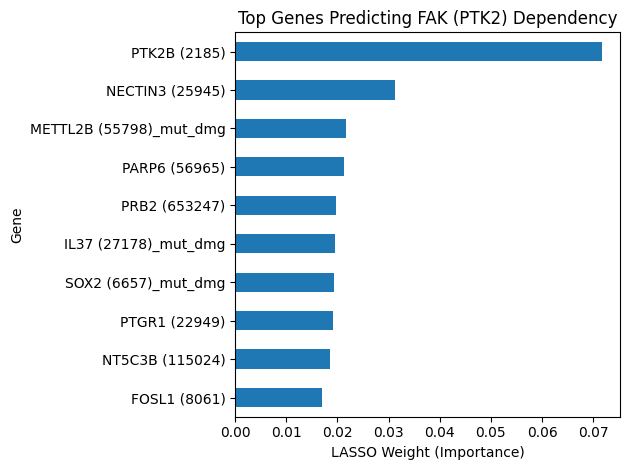

In [37]:
import matplotlib.pyplot as plt

print("Day 6 — visualizing top FAK-associated genes")

# Take top 10 genes
top10 = top_genes.head(10)

plt.figure(figsize=(8, 5))
top10.sort_values(by=top10.columns[0]).plot(
    kind="barh",
    legend=False
)

plt.xlabel("LASSO Weight (Importance)")
plt.ylabel("Gene")
plt.title("Top Genes Predicting FAK (PTK2) Dependency")

plt.tight_layout()
plt.show()

graphs top ten genes

In [42]:
# Ensure top_genes is a DataFrame
if isinstance(top_genes, pd.Series):
    top_genes = top_genes.to_frame(name="LASSO_weight")

# Re-create Feature_type safely
def feature_type(name):
    name = str(name)
    if "_mut_dmg" in name:
        return "Damaging mutation"
    if "_cnv" in name:
        return "CNV loss"
    return "Expression"

top_genes["Feature_type"] = top_genes.index.map(feature_type)

top_genes

,LASSO_weight,Feature_type
PTK2B (2185),0.071654,Expression
NECTIN3 (25945),0.031159,Expression
METTL2B (55798)_mut_dmg,0.021684,Damaging mutation
PARP6 (56965),0.021231,Expression
PRB2 (653247),0.019667,Expression
IL37 (27178)_mut_dmg,0.019470,Damaging mutation
SOX2 (6657)_mut_dmg,0.019389,Damaging mutation
PTGR1 (22949),0.019155,Expression
NT5C3B (115024),0.018601,Expression
FOSL1 (8061),0.016998,Expression


turns raw LASSO coefficiants into a readable biology table

In [43]:
top_genes.groupby("Feature_type").size()

Feature_type
Damaging mutation     9
Expression           11
dtype: int64

groups gened and counts top genes

In [1]:
import pandas as pd

print("Day 8 — loading final artifacts...")

# Load biomarker matrix
X = pd.read_csv("outputs/X_biomarkers.csv")
print("X shape:", X.shape)

# Load regression target
y = pd.read_csv("outputs/y_fak_regression.csv", index_col=0)
print("y shape:", y.shape)

# Load top genes from LASSO
top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0)
print("Top genes loaded:")
display(top_genes.head(10))

Day 8 — loading final artifacts...
X shape: (0, 58513)
y shape: (0, 1)
Top genes loaded:


,0
PTK2B (2185),0.071654
NECTIN3 (25945),0.031159
METTL2B (55798)_mut_dmg,0.021684
PARP6 (56965),0.021231
PRB2 (653247),0.019667
IL37 (27178)_mut_dmg,0.019470
SOX2 (6657)_mut_dmg,0.019389
PTGR1 (22949),0.019155
NT5C3B (115024),0.018601
FOSL1 (8061),0.016998


Loads previous data and confirms the results are correct and reproducible

Also, using a LASSO regression model, we identified a small set of genes most strongly associated with dependency on FAK (PTK2) across cancer cell lines. The top-ranked gene, PTK2B, is biologically related to PTK2 and supports the validity of the model. Other influential genes include both expression-based features and damaging mutation features, indicating that FAK dependency is influenced by multiple molecular mechanisms. The sparsity of the model suggests that only a limited subset of genes is necessary to explain a significant portion of the variation in FAK dependency.

## Limitations

This analysis relies on linear modeling, which may not fully capture complex nonlinear relationships between genes and FAK dependency.

The dataset contains a high number of features compared to the number of samples, which increases the risk of overfitting despite LASSO regularization.

Additionally, dependency scores are derived from in vitro cell line experiments and may not fully represent tumor behavior in patients.

## Future Work

Future work could apply nonlinear models such as Random Forests or Neural Networks to capture more complex gene interactions.

Pathway-level analysis could be performed to understand how groups of genes jointly influence FAK dependency rather than evaluating genes independently.

Experimental validation, such as gene knockdown studies, would be necessary to confirm whether the identified genes causally affect FAK dependency.